In [1]:
from astroquery.gaia import Gaia
print("✅ astroquery loaded successfully!")

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
✅ astroquery loaded successfully!


In [2]:
# Import everything
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia

# Query Gaia database
query = """
SELECT TOP 5000
    source_id,
    parallax,
    pmra,
    pmdec,
    phot_g_mean_mag,
    bp_rp
FROM gaiadr3.gaia_source
WHERE parallax > 0
AND parallax_over_noise > 10
"""

print("Fetching star data from NASA/ESA Gaia database...")
job = Gaia.launch_job(query)
results = job.get_results()

# Convert to pandas
df = results.to_pandas()

print(f"✅ Done! We fetched {df.shape[0]} stars with {df.shape[1]} features")
df.head()

Fetching star data from NASA/ESA Gaia database...


HTTPError: Error 400: 
Cannot parse query '
SELECT TOP 5000
    source_id,
    parallax,
    pmra,
    pmdec,
    phot_g_mean_mag,
    bp_rp
FROM gaiadr3.gaia_source
WHERE parallax > 0
AND parallax_over_noise > 10
' for job '9a667294-601a-11f1-89ce-bc97e148b76b-O': 1 unresolved identifiers: parallax_over_noise [l.11 c.5 - l.11 c.24] !
 - Unknown column "parallax_over_noise" !


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia

query = """
SELECT TOP 5000
    source_id,
    parallax,
    pmra,
    pmdec,
    phot_g_mean_mag,
    bp_rp
FROM gaiadr3.gaia_source
WHERE parallax > 0
AND ruwe < 1.4
"""

print("Fetching star data from NASA/ESA Gaia database...")
job = Gaia.launch_job(query)
results = job.get_results()

df = results.to_pandas()

print(f"✅ Done! We fetched {df.shape[0]} stars with {df.shape[1]} features")
df.head()

Fetching star data from NASA/ESA Gaia database...
✅ Done! We fetched 5000 stars with 6 features


,source_id,parallax,pmra,pmdec,phot_g_mean_mag,bp_rp
0,137339207152695424,0.984936,-2.118385,-0.981535,19.782421,1.126236
1,137339275872182528,0.899287,-4.033312,0.064073,18.094265,1.775972
2,137339378951397504,0.202655,-0.974523,-1.162527,17.883663,0.929686
3,137339585109844864,0.590569,4.476052,-2.382441,16.444675,0.979592
4,137340276599650176,0.528645,0.209204,-0.636003,15.587063,0.876102


In [4]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

print("\nBasic statistics of our stars:")
df.describe()

Missing values in each column:
source_id           0
parallax            0
pmra                0
pmdec               0
phot_g_mean_mag     2
bp_rp              41
dtype: int64

Basic statistics of our stars:


,source_id,parallax,pmra,pmdec,phot_g_mean_mag,bp_rp
count,5.000000e+03,5000.000000,5000.000000,5000.000000,4998.000000,4959.000000
mean,1.386681e+17,0.863409,2.287644,-3.654117,18.322889,1.546828
std,5.335778e+14,0.959199,8.058650,7.298892,1.871005,0.550053
min,1.373330e+17,0.000534,-42.431153,-164.494129,7.856598,0.029331
25%,1.388303e+17,0.311228,-0.757701,-4.844767,17.290354,1.108260
50%,1.388645e+17,0.619263,0.802601,-2.055045,18.707355,1.395172
75%,1.389142e+17,1.095974,3.534117,-0.506692,19.780577,1.918015
max,1.390128e+17,27.334787,168.292969,39.303488,20.914684,4.945676


In [5]:
# Drop rows with missing values
df_clean = df.dropna()

# Drop source_id — it's just an ID, not a feature
df_clean = df_clean.drop(columns=['source_id'])

# Confirm
print(f"Original data: 5000 rows")
print(f"Clean data: {df_clean.shape[0]} rows")
print(f"Rows dropped: {5000 - df_clean.shape[0]}")
print(f"\nFeatures we will cluster on: {list(df_clean.columns)}")

Original data: 5000 rows
Clean data: 4959 rows
Rows dropped: 41

Features we will cluster on: ['parallax', 'pmra', 'pmdec', 'phot_g_mean_mag', 'bp_rp']


In [6]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean)

# Convert back to DataFrame so we can see it nicely
df_scaled = pd.DataFrame(df_scaled, columns=df_clean.columns)

print("Before scaling - parallax range:")
print(f"  Min: {df_clean['parallax'].min():.3f}, Max: {df_clean['parallax'].max():.3f}")

print("\nAfter scaling - parallax range:")
print(f"  Min: {df_scaled['parallax'].min():.3f}, Max: {df_scaled['parallax'].max():.3f}")

df_scaled.head()

Before scaling - parallax range:
  Min: 0.001, Max: 27.335

After scaling - parallax range:
  Min: -0.899, Max: 27.625


,parallax,pmra,pmdec,phot_g_mean_mag,bp_rp
0,0.128123,-0.546342,0.365860,0.782143,-0.764716
1,0.038747,-0.783947,0.508878,-0.118631,0.416628
2,-0.688205,-0.404411,0.341104,-0.231005,-1.122081
3,-0.283407,0.271899,0.174244,-0.998828,-1.031341
4,-0.348026,-0.257533,0.413122,-1.456437,-1.219506


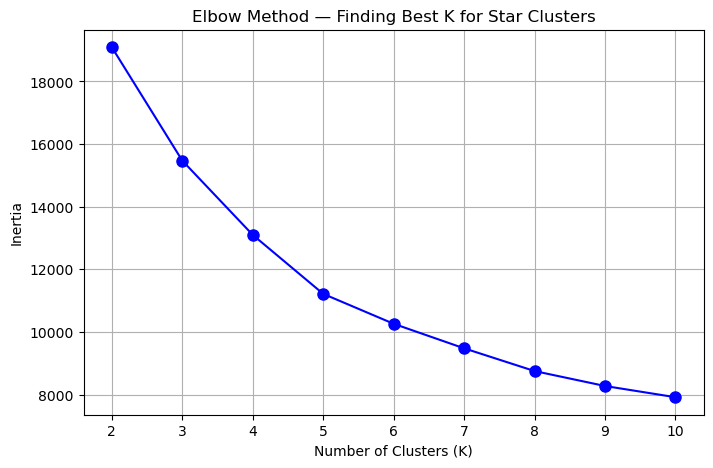

In [7]:
from sklearn.cluster import KMeans

inertias = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)

# Plot the elbow
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Finding Best K for Star Clusters')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [8]:
# Run K-Means with K=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(df_scaled)

# Add cluster labels back to original data
df_clean['cluster'] = kmeans.labels_

# See how many stars in each cluster
print("Stars in each cluster:")
print(df_clean['cluster'].value_counts().sort_index())

Stars in each cluster:
cluster
0       3
1    1450
2    2199
3    1129
4     178
Name: count, dtype: int64


In [9]:
# See the 3 unusual stars
print("The 3 unusual stars in Cluster 0:")
df_clean[df_clean['cluster'] == 0]

The 3 unusual stars in Cluster 0:


,parallax,pmra,pmdec,phot_g_mean_mag,bp_rp,cluster
143,15.553052,133.596817,-164.494129,19.023046,3.790125,0
1816,27.334787,130.837537,-115.713012,7.996255,0.920671,0
2198,10.841435,168.292969,-106.466559,18.047541,3.530098,0


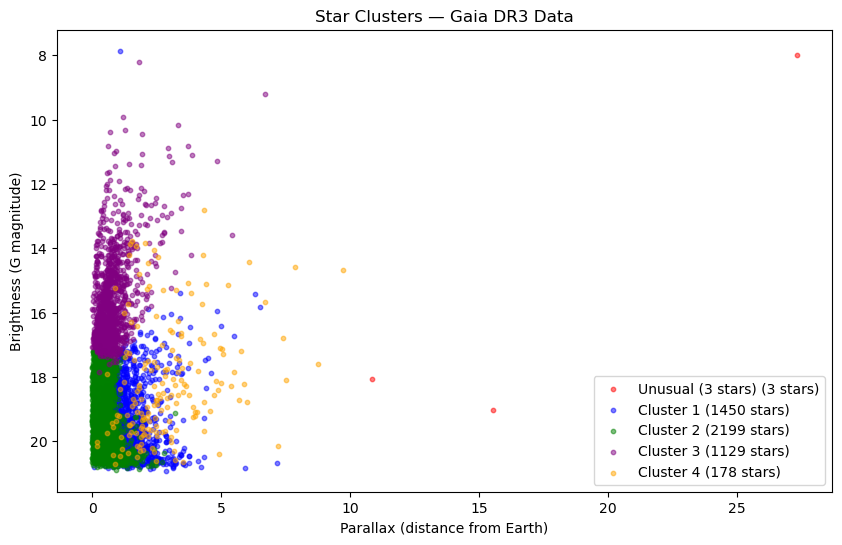

In [10]:
plt.figure(figsize=(10, 6))

colors = ['red', 'blue', 'green', 'purple', 'orange']
labels = ['Unusual (3 stars)', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

for i in range(5):
    mask = df_clean['cluster'] == i
    plt.scatter(
        df_clean[mask]['parallax'],
        df_clean[mask]['phot_g_mean_mag'],
        c=colors[i],
        label=f'{labels[i]} ({mask.sum()} stars)',
        alpha=0.5,
        s=10
    )

plt.xlabel('Parallax (distance from Earth)')
plt.ylabel('Brightness (G magnitude)')
plt.title('Star Clusters — Gaia DR3 Data')
plt.legend()
plt.gca().invert_yaxis()  # Astronomy convention: brighter = lower number
plt.show()

In [11]:
import subprocess
subprocess.check_call([
    'C:\\Atharva vs\\New folder\\python.exe',
    '-m', 'pip', 'install', 'hdbscan'
])
print("✅ HDBSCAN installed!")

✅ HDBSCAN installed!


In [12]:
import hdbscan

# Run HDBSCAN
hdb = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5)
hdb.fit(df_scaled)

# Add labels to dataframe
df_clean['hdb_cluster'] = hdb.labels_

# -1 means noise in HDBSCAN
print("Cluster distribution:")
print(df_clean['hdb_cluster'].value_counts().sort_index())

print(f"\nStars labeled as NOISE (-1): {(hdb.labels_ == -1).sum()}")
print(f"Number of clusters found: {df_clean['hdb_cluster'].nunique() - 1}")

Cluster distribution:
hdb_cluster
-1    4959
Name: count, dtype: int64

Stars labeled as NOISE (-1): 4959
Number of clusters found: 0


In [13]:
hdb = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=3)
hdb.fit(df_scaled)

df_clean['hdb_cluster'] = hdb.labels_

print("Cluster distribution:")
print(df_clean['hdb_cluster'].value_counts().sort_index())

print(f"\nStars labeled as NOISE (-1): {(hdb.labels_ == -1).sum()}")
print(f"Number of clusters found: {df_clean['hdb_cluster'].nunique() - 1}")

Cluster distribution:
hdb_cluster
-1    3074
 0      18
 1      27
 2      24
 3      41
 4    1757
 5      18
Name: count, dtype: int64

Stars labeled as NOISE (-1): 3074
Number of clusters found: 6


In [14]:
hdb = hdbscan.HDBSCAN(min_cluster_size=30, min_samples=3)
hdb.fit(df_scaled)

df_clean['hdb_cluster'] = hdb.labels_

print("Cluster distribution:")
print(df_clean['hdb_cluster'].value_counts().sort_index())

print(f"\nStars labeled as NOISE (-1): {(hdb.labels_ == -1).sum()}")
print(f"Number of clusters found: {df_clean['hdb_cluster'].nunique() - 1}")

Cluster distribution:
hdb_cluster
-1    3031
 0      41
 1    1887
Name: count, dtype: int64

Stars labeled as NOISE (-1): 3031
Number of clusters found: 2


In [15]:
hdb = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=1)
hdb.fit(df_scaled)

df_clean['hdb_cluster'] = hdb.labels_

print("Cluster distribution:")
print(df_clean['hdb_cluster'].value_counts().sort_index())

print(f"\nStars labeled as NOISE (-1): {(hdb.labels_ == -1).sum()}")
print(f"Number of clusters found: {df_clean['hdb_cluster'].nunique() - 1}")

Cluster distribution:
hdb_cluster
-1     2783
 0       24
 1       26
 2       25
 3       45
 4       33
 5       50
 6       27
 7       27
 8       30
 9       27
 10    1862
Name: count, dtype: int64

Stars labeled as NOISE (-1): 2783
Number of clusters found: 11


In [16]:
hdb = hdbscan.HDBSCAN(min_cluster_size=100, min_samples=1)
hdb.fit(df_scaled)

df_clean['hdb_cluster'] = hdb.labels_

print("Cluster distribution:")
print(df_clean['hdb_cluster'].value_counts().sort_index())

print(f"\nStars labeled as NOISE (-1): {(hdb.labels_ == -1).sum()}")
print(f"Number of clusters found: {df_clean['hdb_cluster'].nunique() - 1}")

Cluster distribution:
hdb_cluster
-1    4959
Name: count, dtype: int64

Stars labeled as NOISE (-1): 4959
Number of clusters found: 0


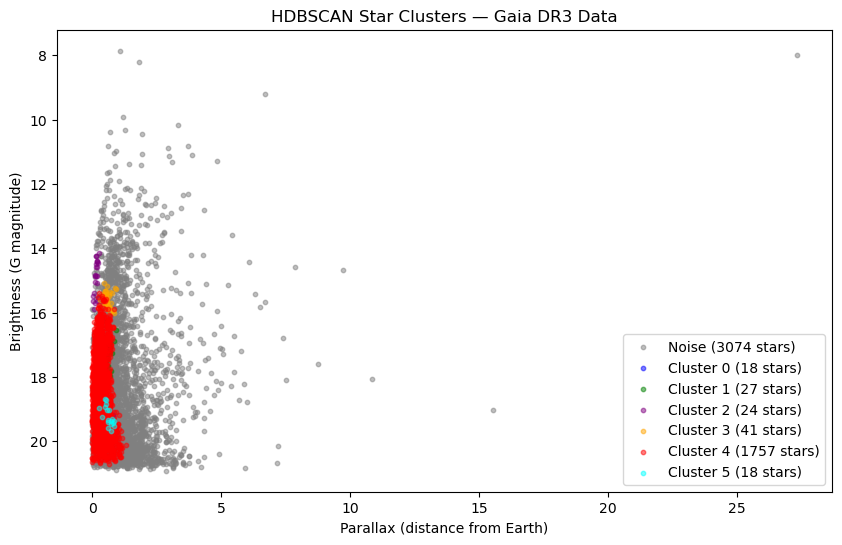

In [17]:
hdb = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=3)
hdb.fit(df_scaled)

df_clean['hdb_cluster'] = hdb.labels_

# Visualize HDBSCAN results
plt.figure(figsize=(10, 6))

colors = ['gray', 'blue', 'green', 'purple', 'orange', 'red', 'cyan']
labels_names = ['Noise', 'Cluster 0', 'Cluster 1', 'Cluster 2', 
                'Cluster 3', 'Cluster 4', 'Cluster 5']

for i, (color, label) in enumerate(zip(colors, labels_names)):
    cluster_id = i - 1  # -1 is noise
    mask = df_clean['hdb_cluster'] == cluster_id
    plt.scatter(
        df_clean[mask]['parallax'],
        df_clean[mask]['phot_g_mean_mag'],
        c=color,
        label=f'{label} ({mask.sum()} stars)',
        alpha=0.5,
        s=10
    )

plt.xlabel('Parallax (distance from Earth)')
plt.ylabel('Brightness (G magnitude)')
plt.title('HDBSCAN Star Clusters — Gaia DR3 Data')
plt.legend()
plt.gca().invert_yaxis()
plt.show()

In [18]:
import subprocess
subprocess.check_call([
    'C:\\Atharva vs\\New folder\\python.exe',
    '-m', 'pip', 'install', 'umap-learn'
])
print("✅ UMAP installed!")

✅ UMAP installed!


Running UMAP — this may take 30-60 seconds...


C:\Users\athar\AppData\Roaming\Python\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


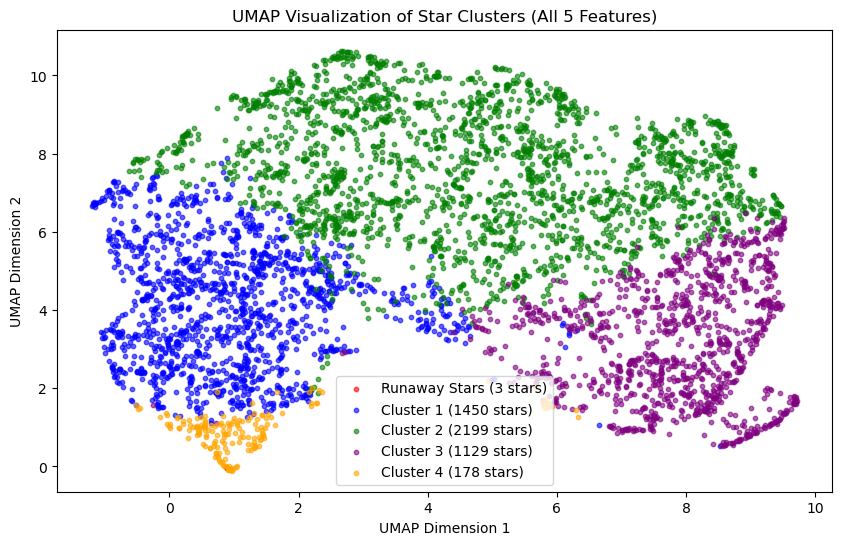

In [19]:
import umap

# Fit UMAP on all 5 scaled features
print("Running UMAP — this may take 30-60 seconds...")
reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(df_scaled)

# Plot with K-Means clusters
plt.figure(figsize=(10, 6))

colors = ['red', 'blue', 'green', 'purple', 'orange']
labels = ['Runaway Stars', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

for i, (color, label) in enumerate(zip(colors, labels)):
    mask = df_clean['cluster'] == i
    plt.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        c=color,
        label=f'{label} ({mask.sum()} stars)',
        alpha=0.6,
        s=10
    )

plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.title('UMAP Visualization of Star Clusters (All 5 Features)')
plt.legend()
plt.show()

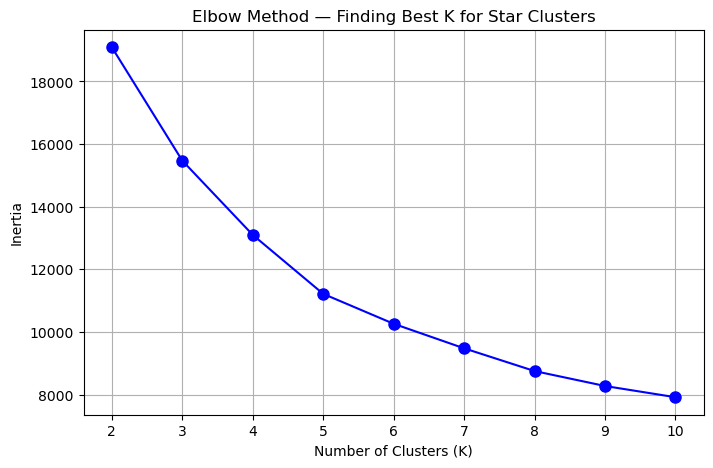

✅ Elbow plot saved!


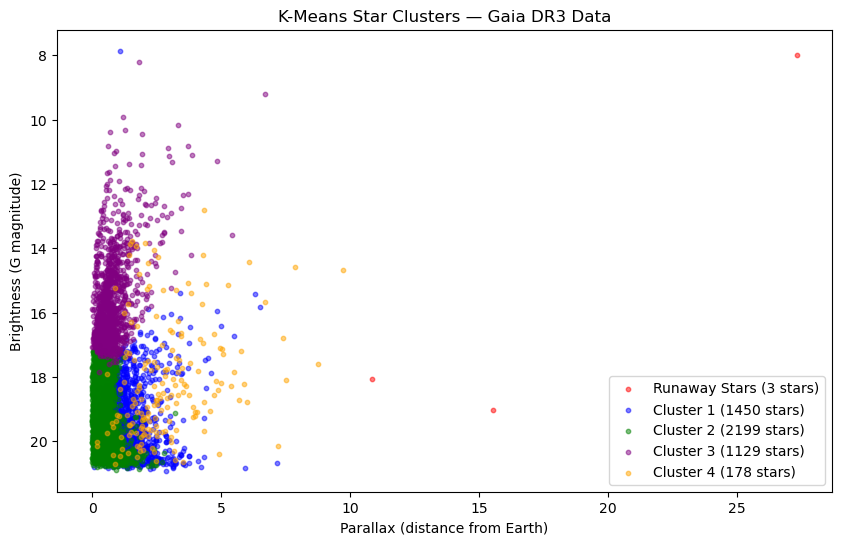

✅ K-Means plot saved!


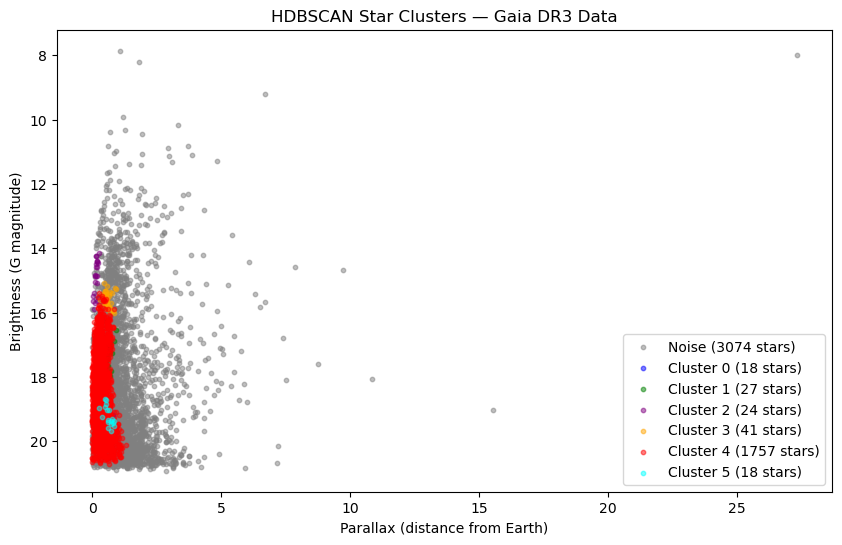

✅ HDBSCAN plot saved!


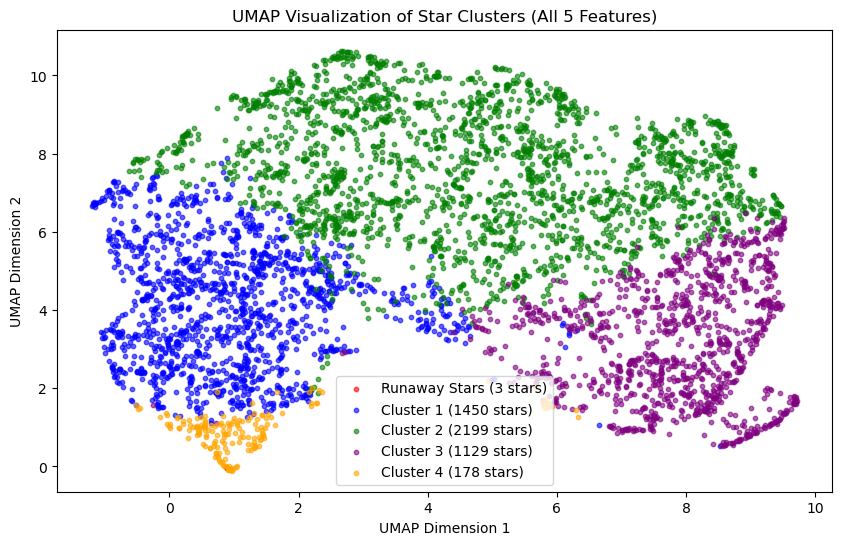

✅ UMAP plot saved!

✅ All 4 images saved in images/ folder!


In [20]:
import os
os.makedirs('images', exist_ok=True)

# Re-run and save Elbow plot
inertias = []
k_values = range(2, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Finding Best K for Star Clusters')
plt.xticks(k_values)
plt.grid(True)
plt.savefig('images/elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Elbow plot saved!")

# Save K-Means plot
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green', 'purple', 'orange']
labels = ['Runaway Stars', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']
for i, (color, label) in enumerate(zip(colors, labels)):
    mask = df_clean['cluster'] == i
    plt.scatter(df_clean[mask]['parallax'], df_clean[mask]['phot_g_mean_mag'],
                c=color, label=f'{label} ({mask.sum()} stars)', alpha=0.5, s=10)
plt.xlabel('Parallax (distance from Earth)')
plt.ylabel('Brightness (G magnitude)')
plt.title('K-Means Star Clusters — Gaia DR3 Data')
plt.legend()
plt.gca().invert_yaxis()
plt.savefig('images/kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ K-Means plot saved!")

# Save HDBSCAN plot
hdb = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=3)
hdb.fit(df_scaled)
df_clean['hdb_cluster'] = hdb.labels_
plt.figure(figsize=(10, 6))
colors2 = ['gray', 'blue', 'green', 'purple', 'orange', 'red', 'cyan']
labels2 = ['Noise', 'Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5']
for i, (color, label) in enumerate(zip(colors2, labels2)):
    mask = df_clean['hdb_cluster'] == (i - 1)
    plt.scatter(df_clean[mask]['parallax'], df_clean[mask]['phot_g_mean_mag'],
                c=color, label=f'{label} ({mask.sum()} stars)', alpha=0.5, s=10)
plt.xlabel('Parallax (distance from Earth)')
plt.ylabel('Brightness (G magnitude)')
plt.title('HDBSCAN Star Clusters — Gaia DR3 Data')
plt.legend()
plt.gca().invert_yaxis()
plt.savefig('images/hdbscan_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ HDBSCAN plot saved!")

# Save UMAP plot
plt.figure(figsize=(10, 6))
for i, (color, label) in enumerate(zip(colors, labels)):
    mask = df_clean['cluster'] == i
    plt.scatter(embedding[mask, 0], embedding[mask, 1],
                c=color, label=f'{label} ({mask.sum()} stars)', alpha=0.6, s=10)
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.title('UMAP Visualization of Star Clusters (All 5 Features)')
plt.legend()
plt.savefig('images/umap_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ UMAP plot saved!")

print("\n✅ All 4 images saved in images/ folder!")

In [21]:
# Save requirements.txt
requirements = """astroquery==0.4.11
pandas
numpy
matplotlib
scikit-learn
hdbscan
umap-learn
jupyter
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("✅ requirements.txt saved!")

✅ requirements.txt saved!


In [22]:
import os
print(os.getcwd())

C:\Users\athar
